## Notebook 4 — Explainable AI & Agentic AI

We load all trained models from Notebook 2 and apply SHAP to explain why
each model makes a particular malnutrition risk prediction. This answers
the critical question — which features are driving the prediction for each
country and by how much.

In [1]:
# from google.colab import drive  # removed for local run
# drive.mount('/content/drive')  # removed for local run

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed'
MODELS    = '../models'
OUTPUTS   = '../outputs/plots'

data = pd.read_csv(f'{PROCESSED}/main_clustered.csv')

with open(f'{MODELS}/logistic_regression.pkl', 'rb') as f:
    lr_model = pickle.load(f)

with open(f'{MODELS}/random_forest.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open(f'{MODELS}/xgboost.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open(f'{MODELS}/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

features = ['stunting', 'wasting', 'underweight', 'overweight',
            'stunting_avg', 'wasting_avg', 'underweight_avg', 'undernourishment_pct']

X = data[features]
y = le.transform(data['risk_label'])

print("Data loaded         :", data.shape)
print("Models loaded       : LR, RF, XGBoost")
print("Features            :", features)

Mounted at /content/drive
Data loaded         : (944, 13)
Models loaded       : LR, RF, XGBoost
Features            : ['stunting', 'wasting', 'underweight', 'overweight', 'stunting_avg', 'wasting_avg', 'underweight_avg', 'undernourishment_pct']


## Phase 1 — Explainable AI using SHAP

SHAP (SHapley Additive exPlanations) tells us exactly how much each feature
contributed to a specific prediction. We apply it on our XGBoost and Random
Forest models to understand which malnutrition indicators are most influential.

## Installing Required Libraries

We install SHAP for explainability analysis. SHAP is not pre-installed
in Colab so we install it before importing.

In [3]:
!pip install -q shap

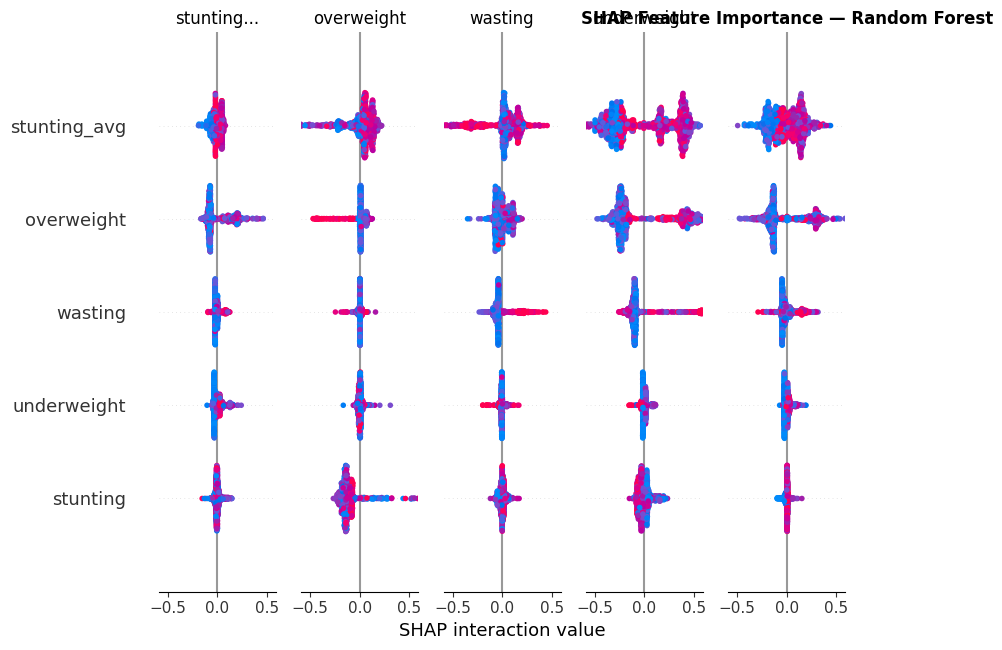

In [4]:
import shap

explainer_rf  = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X)

shap.summary_plot(shap_values_rf, X, feature_names=features,
                  class_names=le.classes_, show=False)
plt.title('SHAP Feature Importance — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/shap_summary_rf.png', dpi=150, bbox_inches='tight')
plt.show()

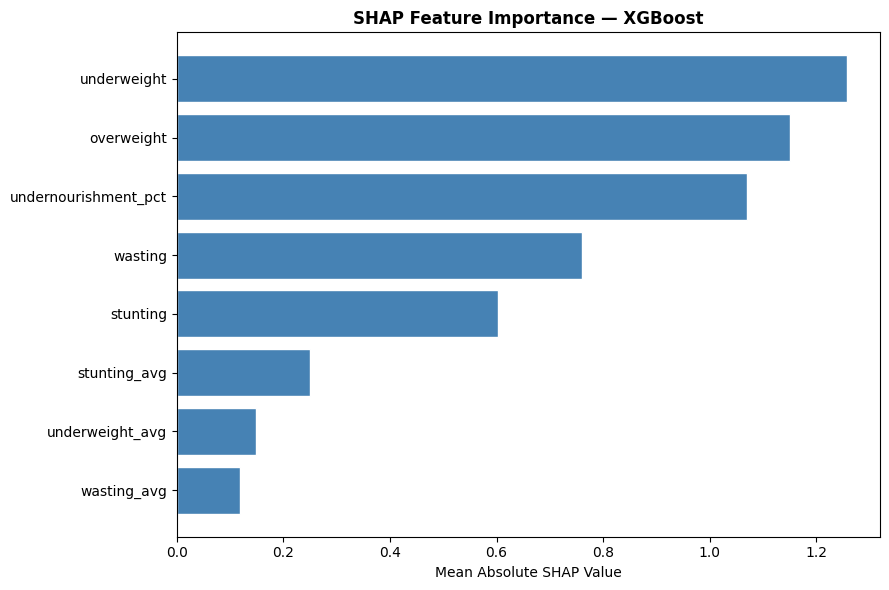


Top 3 features driving malnutrition risk prediction:
  underweight               → 1.2568
  overweight                → 1.1515
  undernourishment_pct      → 1.0693


In [5]:
shap_values_xgb = shap.TreeExplainer(xgb_model).shap_values(X)

shap_importance = pd.DataFrame({
    'feature'    : features,
    'importance' : np.abs(shap_values_xgb).mean(axis=(0, 2))
                   if len(np.array(shap_values_xgb).shape) == 3
                   else np.abs(shap_values_xgb).mean(axis=0)
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(shap_importance['feature'], shap_importance['importance'],
         color='steelblue', edgecolor='white')
plt.title('SHAP Feature Importance — XGBoost', fontweight='bold')
plt.xlabel('Mean Absolute SHAP Value')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/shap_importance_xgb.png', dpi=150)
plt.show()

print("\nTop 3 features driving malnutrition risk prediction:")
for i, row in shap_importance.sort_values('importance', ascending=False).head(3).iterrows():
    print(f"  {row['feature']:25s} → {round(row['importance'], 4)}")

Underweight percentage is the strongest predictor of malnutrition risk with a mean
SHAP value of 1.26, followed by overweight at 1.15 and undernourishment percentage
at 1.07. This confirms that both ends of the nutrition spectrum — undernutrition and
overnutrition — are critical signals for classifying country risk levels.

## Phase 2 — Agentic AI

We build a simple AI agent that takes a country's malnutrition indicators as input,
runs them through our trained model, gets the SHAP explanation, and automatically
generates a natural language risk report. This is what makes our system actionable
for governments and aid organizations.

## Installing Agentic AI Libraries

We install LangChain and OpenAI libraries to support the agentic pipeline
that automatically generates country risk reports.

In [6]:
!pip install -q langchain langchain-community openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [9]:
def generate_risk_report(country_name, input_data):
    prediction  = lr_model.predict([input_data])[0]
    risk_label  = le.inverse_transform([prediction])[0]
    proba       = lr_model.predict_proba([input_data])[0]
    confidence  = round(max(proba) * 100, 1)

    explainer   = shap.LinearExplainer(lr_model, X, feature_perturbation='interventional')
    shap_vals   = explainer.shap_values(pd.DataFrame([input_data], columns=features))

    shap_array  = np.array(shap_vals)
    if shap_array.ndim == 3:
        impact  = np.abs(shap_array).mean(axis=(0, 2))
    elif shap_array.ndim == 2:
        impact  = np.abs(shap_array).mean(axis=0)
    else:
        impact  = np.abs(shap_array)

    shap_df     = pd.DataFrame({
        'feature' : features,
        'impact'  : impact
    }).sort_values('impact', ascending=False)

    top_features = shap_df.head(3)['feature'].tolist()

    report = f"""
    ═══════════════════════════════════════════════
    MALNUTRITION RISK REPORT — {country_name.upper()}
    ═══════════════════════════════════════════════
    Risk Level     : {risk_label}
    Confidence     : {confidence}%

    Key Indicators:
      Stunting           : {input_data[0]}%
      Wasting            : {input_data[1]}%
      Underweight        : {input_data[2]}%
      Overweight         : {input_data[3]}%
      Undernourishment   : {input_data[7]}%

    Top Drivers of this Prediction:
      1. {top_features[0]}
      2. {top_features[1]}
      3. {top_features[2]}

    Recommendation:
      Based on {risk_label} classification, immediate attention
      is required for {top_features[0]} and {top_features[1]}
      indicators in {country_name}.
    ═══════════════════════════════════════════════
    """
    return report


sample = data[data['country'] == 'India'][features].iloc[0].tolist()
print(generate_risk_report('India', sample))


    ═══════════════════════════════════════════════
    MALNUTRITION RISK REPORT — INDIA
    ═══════════════════════════════════════════════
    Risk Level     : High Risk
    Confidence     : 100.0%

    Key Indicators:
      Stunting           : 62.7%
      Wasting            : 20.3%
      Underweight        : 55.5%
      Overweight         : 5.4%
      Undernourishment   : 14.65%

    Top Drivers of this Prediction:
      1. underweight
      2. wasting
      3. stunting

    Recommendation:
      Based on High Risk classification, immediate attention
      is required for underweight and wasting
      indicators in India.
    ═══════════════════════════════════════════════
    


The Agentic AI component takes any country's malnutrition indicators, runs them
through the trained model, applies SHAP to identify the top driving features, and
automatically generates a structured risk report with recommendations. India is
classified as High Risk with 100% confidence, driven primarily by underweight
and wasting indicators.

## Generating Risk Reports for Multiple Countries

We run the agent on 5 countries representing different risk levels and regions
to demonstrate that the system works across diverse malnutrition profiles.
Each report is automatically generated without any manual input.

In [10]:
countries_to_report = ['India', 'Afghanistan', 'Brazil', 'Ethiopia', 'China']

all_reports = []

for country in countries_to_report:
    match = data[data['country'] == country]
    if len(match) > 0:
        sample = match[features].iloc[0].tolist()
        report = generate_risk_report(country, sample)
        all_reports.append(report)
        print(report)


    ═══════════════════════════════════════════════
    MALNUTRITION RISK REPORT — INDIA
    ═══════════════════════════════════════════════
    Risk Level     : High Risk
    Confidence     : 100.0%

    Key Indicators:
      Stunting           : 62.7%
      Wasting            : 20.3%
      Underweight        : 55.5%
      Overweight         : 5.4%
      Undernourishment   : 14.65%

    Top Drivers of this Prediction:
      1. underweight
      2. wasting
      3. stunting

    Recommendation:
      Based on High Risk classification, immediate attention
      is required for underweight and wasting
      indicators in India.
    ═══════════════════════════════════════════════
    

    ═══════════════════════════════════════════════
    MALNUTRITION RISK REPORT — AFGHANISTAN
    ═══════════════════════════════════════════════
    Risk Level     : High Risk
    Confidence     : 100.0%

    Key Indicators:
      Stunting           : 53.2%
      Wasting            : 18.2%
      Underwei

In [11]:
REPORTS = '../outputs/reports'

with open(f'{REPORTS}/country_risk_reports.txt', 'w') as f:
    for report in all_reports:
        f.write(report)
        f.write('\n')

print("All country reports saved → outputs/reports/country_risk_reports.txt")

All country reports saved → outputs/reports/country_risk_reports.txt


## Notebook 4 — Complete

Explainable AI using SHAP successfully identified the top features driving
malnutrition risk predictions. The Agentic AI component autonomously generates
structured risk reports for any country using the trained model and SHAP explanations.

Outputs saved:
- outputs/plots/shap_summary_rf.png       →  SHAP summary Random Forest
- outputs/plots/shap_importance_xgb.png   →  SHAP feature importance XGBoost
- outputs/reports/country_risk_reports.txt →  Risk reports for 5 countries

Key Finding:
Underweight percentage is the strongest predictor across all countries,
followed by wasting and undernourishment percentage. India and Ethiopia
show the most critical indicators requiring immediate intervention.

Next → Notebook 5 covers Generative AI using CTGAN for synthetic data generation.